In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Pareto: TPU v5p pod vs GB200 NVL72 — GPT-1.8T MoE (FP4), S_decode=8k

**Question:** how does the (throughput/GPU, interactivity) Pareto frontier shift when the *collective-algorithm* choice changes (AR, MoE A2A, AG) on each fabric?

Two fabrics × two algorithm variants = **4 frontiers on one figure**. Each variant swaps the full collective set on the dispatcher, not just AR:

| Variant | Fabric | Collectives on the dispatcher (AR / MoE A2A / AG) |
|---|---|---|
| `tpu.flat-ring`  | `tpu.v5p.pod` (3D torus 16³, N=4096)           | dim-by-dim torus routing *only if G is a prefix product of (16,16,16)*; otherwise flat-ring fallback on all three collectives |
| `tpu.dim-ring`   | `tpu.v5p.pod`                                   | greedy-subset factorization routes *every* G through the dim-decomposed torus primitives on all three collectives |
| `gb200.ring`     | `gb200.72gpu` (single-tier NVLink crossbar, N=72) | ring AR + ring MoE A2A + ring AG |
| `gb200.dbt`      | `gb200.72gpu`                                   | double-binary-tree on AR and MoE A2A (AG stays ring — no tree-AG primitive) |

Both fabrics are running the same GPT-1.8T MoE model at FP4 with `S_decode=8192`. Only frontiers are plotted (no clouds) so the algorithm deltas are easy to read.

_Note: the two clusters are very different in device count (4096 vs 72). The y-axis (throughput/GPU) and x-axis (interactivity) are per-device/per-user metrics, so the comparison stays meaningful — but peak **aggregate** throughput (TTPS) is not shown here, and scales with cluster size._

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import itertools
import warnings
from dataclasses import replace
from typing import List, Tuple

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.collective_algo_opt import optimize_collective_algorithms
from llm_perf.core.primitives import dispatch as _dispatch
from llm_perf.io import (
    load_model_from_db,
    load_partition_from_db,
    load_system_from_db,
    load_tuner_from_db,
)

MODEL_ID = 'gpt_1_8t_moe'
TUNER_ID = 'gpt_1_8t_moe.tuner'
PARTITION_ID = 'example.partition'
TPU_ID = 'tpu.v5p.pod'
GB_ID = 'gb200.72gpu'

S_DECODE = 8192
BPP_FP4 = 0.5

model = load_model_from_db(MODEL_ID)
model.bytes_per_param = BPP_FP4
partition_tmpl = load_partition_from_db(PARTITION_ID)
tuner_base = load_tuner_from_db(TUNER_ID)
tuner_base = replace(tuner_base, S_decode=S_DECODE, B_decode=1)

sys_tpu = load_system_from_db(TPU_ID)
sys_gb  = load_system_from_db(GB_ID)

def fabric_summary(system):
    # Pick the first (and usually only) fabric tier for single-tier fabrics; fall back gracefully for multi-tier.
    fab_name, fab = next(iter(system.fabrics.items()))
    tier = fab.tiers[0]
    bw = getattr(tier, 'bw_per_port_GBps', None)
    alpha = getattr(tier, 'alpha_us', None)
    return fab_name, bw, alpha

tpu_fab, tpu_bw, tpu_alpha = fabric_summary(sys_tpu)
gb_fab,  gb_bw,  gb_alpha  = fabric_summary(sys_gb)

print(f'Model : {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  b={model.bytes_per_param}')
print(f'TPU   : {sys_tpu.name}  N={sys_tpu.num_devices}  HBM={sys_tpu.device.hbm_bandwidth_GBps:.0f} GB/s  peak={sys_tpu.device.peak_flops_TF:.0f} TF  {tpu_fab}={tpu_bw:.0f} GB/s/port  α={tpu_alpha:.1f} μs')
print(f'GB200 : {sys_gb.name}  N={sys_gb.num_devices}  HBM={sys_gb.device.hbm_bandwidth_GBps:.0f} GB/s  peak={sys_gb.device.peak_flops_TF:.0f} TF  {gb_fab}={gb_bw:.0f} GB/s/port  α={gb_alpha:.1f} μs')

Model : GPT-1.8T-MoE  L=120  H=20480  n_kv=16  b=0.5
TPU   : tpu_v5p_pod  N=4096  HBM=2765 GB/s  peak=459 TF  ici=150 GB/s/port  α=1.0 μs
GB200 : gb200_nvl72  N=72  HBM=8000 GB/s  peak=9000 TF  nvlink5=900 GB/s/port  α=0.5 μs


## 2. Sweep space

Divisibility constraints come from the model: `PP | L=120`, `TP | n_kv=16`, `EP | n_experts=16`. `SP=1` (no ring attention). Batch `B` sweeps a geometric ladder up to 256.

Partitions that don't factor the device count (DP = N/(PP·TP·EP·SP) must be a positive integer) are filtered per-system.

In [3]:
PP_VALUES = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60]
TP_VALUES = [1, 2, 4, 8, 16]
EP_VALUES = [1, 2, 4, 8, 16]
SP_VALUES = [1, 2, 4, 8, 16, 32, 64]
B_VALUES  = [1, 2, 4, 8, 16, 32, 64, 128, 256]

def is_valid(PP, TP, EP, SP, N):
    prod = PP * TP * EP * SP
    return prod > 0 and prod <= N and N % prod == 0

n_part_tpu = sum(1 for PP,TP,EP,SP in itertools.product(PP_VALUES,TP_VALUES,EP_VALUES,SP_VALUES) if is_valid(PP,TP,EP,SP,sys_tpu.num_devices))
n_part_gb  = sum(1 for PP,TP,EP,SP in itertools.product(PP_VALUES,TP_VALUES,EP_VALUES,SP_VALUES) if is_valid(PP,TP,EP,SP,sys_gb.num_devices))
print(f'Valid (PP,TP,EP,SP) partitions: TPU={n_part_tpu}  GB200={n_part_gb}')
print(f'Batch ladder: {B_VALUES}')

Valid (PP,TP,EP,SP) partitions: TPU=631  GB200=70
Batch ladder: [1, 2, 4, 8, 16, 32, 64, 128, 256]


## 3. TPU dim-ring patch

Default `_dispatch._align_to_dims` only accepts G as a prefix product of the torus dims. Non-prefix Gs fall through to flat ring. The patch below greedily factors G into a subsequence of the axis dims, so every G routes through the dim-decomposed ring primitive — `t_AR = 2·Σ(D_i-1)·α + 2(G-1)/G·M/BW` instead of the flat-ring `2(G-1)·α + 2(G-1)/G·M/BW`.

In [4]:
def greedy_align(G: int, dims: Tuple[int, ...]) -> Tuple[Tuple[int, ...], bool]:
    sub: List[int] = []
    remaining = G
    for d in dims:
        if remaining == 1:
            break
        if remaining == d:
            sub.append(d); remaining = 1; break
        if remaining % d == 0:
            sub.append(d); remaining //= d
        elif d % remaining == 0:
            sub.append(remaining); remaining = 1; break
        else:
            return dims, False
    return (tuple(sub), True) if remaining == 1 else (dims, False)

_original_align = _dispatch._align_to_dims  # save to restore after the dim-ring sweep

## 4. Sweep runner

For each (PP, TP, EP, SP, B) that fits the system and model, evaluate `InferenceCalculator`. Keep only points where the partition fits HBM and latency is positive. Return `(interactivity, throughput_per_GPU, metadata)` tuples.

In [5]:
def run_sweep(system, tuner, *, tag: str, optimize: bool = False):
    pts = []
    feas = infeas = 0
    N = system.num_devices
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        for PP, TP, EP, SP in itertools.product(PP_VALUES, TP_VALUES, EP_VALUES, SP_VALUES):
            if not is_valid(PP, TP, EP, SP, N):
                continue
            partition = replace(partition_tmpl, PP=PP, TP=TP, EP=EP, SP=SP)
            for B in B_VALUES:
                t = replace(tuner, B_decode=B)
                if optimize:
                    t = optimize_collective_algorithms(model, partition, system, t)
                try:
                    r = InferenceCalculator(model, system, partition, t).run()
                except Exception:
                    infeas += 1; continue
                if (not r.memory.fits_in_HBM) or r.latency.TPOT <= 0 or r.latency.TTPS <= 0:
                    infeas += 1; continue
                feas += 1
                pts.append((
                    1.0 / r.latency.TPOT,
                    r.latency.TTPS / N,
                    {'PP': PP, 'TP': TP, 'EP': EP, 'SP': SP, 'B': B,
                     'TPOT_ms': r.latency.TPOT * 1000},
                ))
    print(f'[{tag:18s}] feasible={feas:5d}  infeasible={infeas:5d}')
    return pts

def pareto_upper(points):
    frontier = []
    for p in points:
        if not any(q is not p and q[0] >= p[0] and q[1] >= p[1] and (q[0] > p[0] or q[1] > p[1]) for q in points):
            frontier.append(p)
    frontier.sort(key=lambda t: t[0])
    return frontier

## 5. Run all four variants

TPU variants: swap `_align_to_dims` between the stock (prefix-only) and greedy versions — this affects *every* torus-routed collective (AR, MoE A2A, AG).

GB200 variants: toggle both `tuner.tp_algorithm` (AR) **and** `tuner.ep_algorithm` (MoE A2A) between `"ring"` and `"tree"` so each variant is a coherent algorithm choice across the whole stack.

In [6]:
tuner_ring = replace(tuner_base, tp_algorithm='ring', ep_algorithm='ring')
tuner_auto = replace(tuner_base,
                     tp_algorithm_decode='auto', tp_algorithm_prefill='auto',
                     ep_algorithm_decode='auto', ep_algorithm_prefill='auto')

# TPU — stock align (flat-ring fallback on non-prefix G), worst-case dispatch.
_dispatch._align_to_dims = _original_align
pts_tpu_flat = run_sweep(sys_tpu, tuner_ring, tag='tpu.flat-ring')

# TPU — greedy align (dim-ring everywhere) + optimizer (auto picks torus-dim-ring,
# the only shipped torus option; this serves as the optimized TPU baseline).
_dispatch._align_to_dims = greedy_align
pts_tpu_opt = run_sweep(sys_tpu, tuner_auto, tag='tpu.optimized', optimize=True)
_dispatch._align_to_dims = _original_align  # restore for GB200 runs

# GB200 — ring (worst-case, manual: pin every collective to ring).
pts_gb_ring = run_sweep(sys_gb, tuner_ring, tag='gb200.ring')

# GB200 — optimizer (auto: ring vs DBT picked per (phase × collective × M)).
pts_gb_opt = run_sweep(sys_gb, tuner_auto, tag='gb200.optimized', optimize=True)

frontiers = {
    'tpu.flat-ring' : pareto_upper(pts_tpu_flat),
    'tpu.optimized' : pareto_upper(pts_tpu_opt),
    'gb200.ring'    : pareto_upper(pts_gb_ring),
    'gb200.optimized': pareto_upper(pts_gb_opt),
}
for tag, f in frontiers.items():
    print(f'{tag:16s} frontier points: {len(f)}')

[tpu.flat-ring     ] feasible= 4245  infeasible= 1434


[tpu.optimized     ] feasible= 4245  infeasible= 1434
[gb200.ring        ] feasible=  332  infeasible=  298
[gb200.optimized   ] feasible=  332  infeasible=  298


tpu.flat-ring    frontier points: 7
tpu.optimized    frontier points: 9
gb200.ring       frontier points: 7
gb200.optimized  frontier points: 7


## 6. Plot — four frontiers, one figure

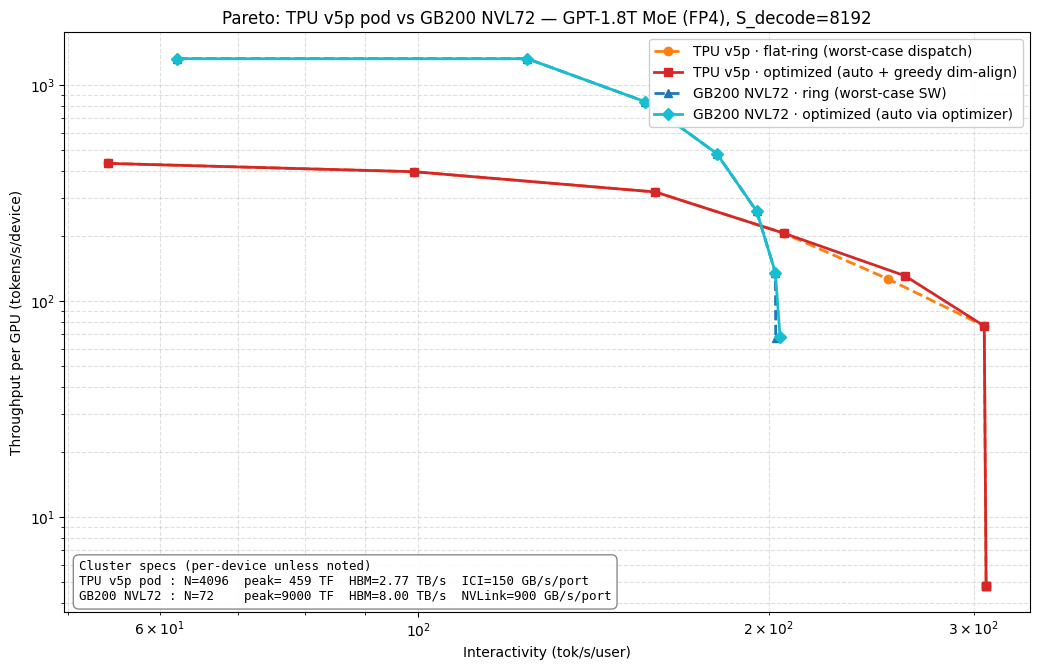

In [7]:
STYLE = {
    'tpu.flat-ring'  : dict(color='tab:orange', marker='o', linestyle='--', label='TPU v5p · flat-ring (worst-case dispatch)'),
    'tpu.optimized'  : dict(color='tab:red',    marker='s', linestyle='-',  label='TPU v5p · optimized (auto + greedy dim-align)'),
    'gb200.ring'     : dict(color='tab:blue',   marker='^', linestyle='--', label='GB200 NVL72 · ring (worst-case SW)'),
    'gb200.optimized': dict(color='tab:cyan',   marker='D', linestyle='-',  label='GB200 NVL72 · optimized (auto via optimizer)'),
}

fig, ax = plt.subplots(figsize=(10.5, 6.8))
for tag, frontier in frontiers.items():
    xs = [p[0] for p in frontier]
    ys = [p[1] for p in frontier]
    ax.plot(xs, ys, linewidth=2, markersize=6, **STYLE[tag])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Interactivity (tok/s/user)')
ax.set_ylabel('Throughput per GPU (tokens/s/device)')
ax.set_title(f'Pareto: TPU v5p pod vs GB200 NVL72 — GPT-1.8T MoE (FP4), S_decode={S_DECODE}')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(loc='upper right', framealpha=0.95)

# Cluster-spec annotation box (flops, HBM BW, I/O BW, device count).
spec_lines = [
    'Cluster specs (per-device unless noted)',
    f'TPU v5p pod : N={sys_tpu.num_devices:<4d}  peak={sys_tpu.device.peak_flops_TF:>4.0f} TF  HBM={sys_tpu.device.hbm_bandwidth_GBps/1000:.2f} TB/s  ICI={tpu_bw:.0f} GB/s/port',
    f'GB200 NVL72 : N={sys_gb.num_devices:<4d}  peak={sys_gb.device.peak_flops_TF:>4.0f} TF  HBM={sys_gb.device.hbm_bandwidth_GBps/1000:.2f} TB/s  NVLink={gb_bw:.0f} GB/s/port',
]
ax.text(0.015, 0.015, '\n'.join(spec_lines),
        transform=ax.transAxes, fontsize=9, family='monospace',
        verticalalignment='bottom', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='gray', alpha=0.92))

fig.tight_layout()
fig.savefig('assets/pareto_tpu_vs_gb200.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Frontier peaks — quick numerical comparison

In [8]:
print(f"{'variant':18s}  {'peak tput/GPU':>13s}  {'peak interact':>14s}  {'winning (PP,TP,EP,B) at peak-y':s}")
print('-' * 90)
for tag, frontier in frontiers.items():
    if not frontier:
        continue
    peak_y = max(frontier, key=lambda p: p[1])
    peak_x = max(frontier, key=lambda p: p[0])
    m = peak_y[2]
    print(f"{tag:18s}  {peak_y[1]:13.2f}  {peak_x[0]:14.2f}  "
          f"(PP={m['PP']}, TP={m['TP']}, EP={m['EP']}, B={m['B']})")

variant             peak tput/GPU   peak interact  winning (PP,TP,EP,B) at peak-y
------------------------------------------------------------------------------------------
tpu.flat-ring              433.61          307.50  (PP=8, TP=4, EP=1, B=256)
tpu.optimized              433.61          307.50  (PP=8, TP=4, EP=1, B=256)
gb200.ring                1324.05          202.85  (PP=12, TP=1, EP=1, B=256)
gb200.optimized           1324.05          204.58  (PP=12, TP=1, EP=1, B=256)
